In [11]:
import gym
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import rl_utils

In [12]:
class PolicyNet(torch.nn.Module):
    """
        ACtor网络；
        用于构建当前Actor与历史Actor网络实例
    """
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(PolicyNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x), dim=1)
    

class ValueNet(torch.nn.Module):
    """
        Critic网络
        用于构建Critic网络实例
    """
    def __init__(self, state_dim, hidden_dim):
        super(ValueNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

这里有一个地方，在我们学习的时候是直接进行比值的，而这里是先求对数，然后使用自然对数，转换回来；
<br>
理论上的概率：网络输出的动作概率是一个 $0$ 到 $1$ 之间的小数。在复杂的环境里（比如动作空间很大），如果智能体刚开始瞎试，或者对某个动作极度不自信，算出来的概率极有可能会非常非常小，比如 $0.000000001$ ($10^{-9}$)。
<br>
如果旧策略算出的概率是 $10^{-10}$，新策略算出的概率是 $10^{-11}$。在理想数学中，比值是 $0.1$。但在计算机的单精度浮点数（float32）计算中，直接让两个极小的数字相除，极易发生数值下溢出（Underflow），最后除出来的结果可能是 0 / 0，直接导致程序爆出一个 NaN（Not a Number），整个训练瞬间崩溃。

In [13]:
class PPO:
    """
        PPO算法,采用截断方式 
    """
    def __init__(self, state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                 lmbda, epochs, eps, gamma, device):
        """
            初始化
            actor_lr：Actor梯度更新学习率
            critic_lr：Critic梯度更新学习率
            lmbda：广义优势估计参数
            epochs：内层循环更新轮数
            eps：截断参数
            gamma：折扣因子
        """
        # 创建网络实例与优化器
        self.actor = PolicyNet(state_dim, hidden_dim, action_dim).to(device)
        self.critic = ValueNet(state_dim, hidden_dim).to(device)
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(),
                                                lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(),
                                                 lr=critic_lr)
        
        self.gamma = gamma
        self.lmbda = lmbda
        self.epochs = epochs            # 一条序列的数据用来训练轮数
        self.eps = eps                  # PPO中截断范围的参数
        self.device = device

    def take_action(self, state):
        """
            选择动作
        """
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        probs = self.actor(state)

        action_dist = torch.distributions.Categorical(probs)
        action = action_dist.sample()

        return action.item()
    
    def update(self, transition_dict):
        """
            策略更新
            transition_dict：从经验回放池取出的一个批次（Batch）的数据字典
        """
        states = torch.tensor(transition_dict['states'], dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'], dtype=torch.float).view(-1, 1).to(self.device)

        # 计算 Q 值
        td_target = rewards + self.gamma * self.critic(next_states) * (1 - dones)

        # 优势函数
        td_delta = td_target - self.critic(states)

        # 计算广义优势估计（GAE）：把所有的单步 TD 误差按 lambda 参数进行指数加权衰减求和，得到最终的优势矩阵
        advantage = rl_utils.compute_advantage(self.gamma, self.lmbda, td_delta.cpu()).to(self.device)

        # 
        old_log_probs = torch.log(self.actor(states).gather(1, actions)).detach()

        for _ in range(self.epochs):
            # 计算当下策略的动作分布的log
            log_probs = torch.log(self.actor(states).gather(1, actions))

            # 计算重要性采样比率
            ratio = torch.exp(log_probs - old_log_probs)

            surr1 = ratio * advantage                                           # 原始值
            surr2 = torch.clamp(ratio, 1 - self.eps, 1 + self.eps) * advantage  # 截断

            # PPO损失函数
            actor_loss = torch.mean(-torch.min(surr1, surr2))  
            critic_loss = torch.mean(F.mse_loss(self.critic(states), td_target.detach()))

            # 清零梯度
            self.actor_optimizer.zero_grad()
            self.critic_optimizer.zero_grad()

            # 反向传播计算梯度
            actor_loss.backward()
            critic_loss.backward()

            # 执行更新参数
            self.actor_optimizer.step()
            self.critic_optimizer.step()

在车杆环境中训练 PPO 算法。

In [14]:
actor_lr = 1e-3
critic_lr = 1e-2
num_episodes = 500
hidden_dim = 128
gamma = 0.98
lmbda = 0.95
epochs = 10
eps = 0.2
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

env_name = 'CartPole-v0'
env = gym.make(env_name)
env.seed(0)
torch.manual_seed(0)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = PPO(state_dim, hidden_dim, action_dim, actor_lr, critic_lr, lmbda,
            epochs, eps, gamma, device)

return_list = rl_utils.train_on_policy_agent(env, agent, num_episodes)

/home/kk/anaconda3/envs/rl_learn/lib/python3.8/site-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/home/kk/anaconda3/envs/rl_learn/lib/python3.8/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/home/kk/anaconda3/envs/rl_learn/lib/python3.8/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/home/kk/anaconda3/envs/rl_learn/lib/python3.8/site-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked 

Iteration 9: 100%|██████████| 50/50 [00:03<00:00, 13.51it/s, episode=500, return=200.000]


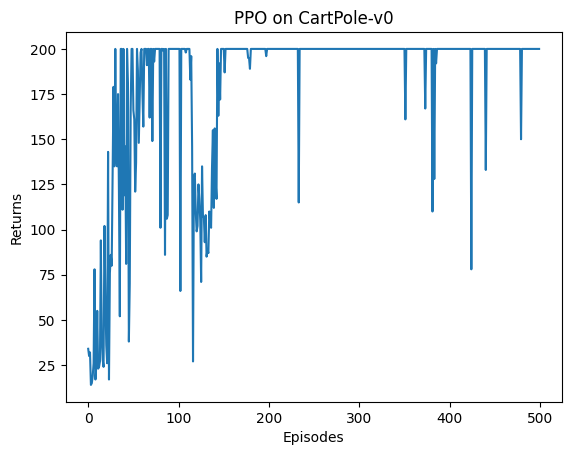

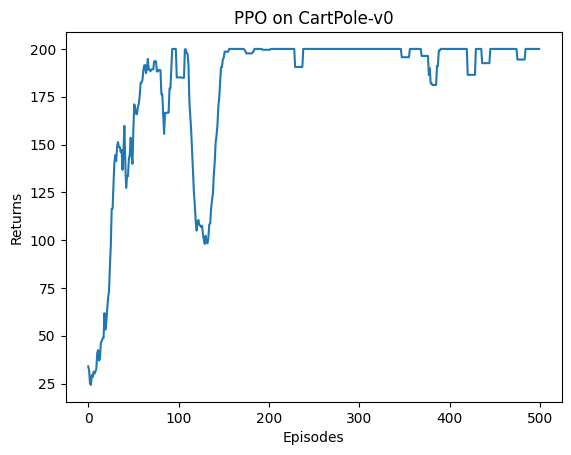

In [15]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('PPO on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('PPO on {}'.format(env_name))
plt.show()

倒立摆是与连续动作交互的环境，同 TRPO 算法一样，我们做一些修改，让策略网络输出连续动作高斯分布（Gaussian distribution）的均值和标准差。后续的连续动作则在该高斯分布中采样得到。

In [16]:
class PolicyNetContinuous(torch.nn.Module):
    """
        连续策略网络
    """
    def __init__(self, state_dim, hidden_dim, action_dim):
        """
            初始化
        """
        super(PolicyNetContinuous, self).__init__()
        # 输入当前状态，提取环境特征
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        # 定义第一颗“脑袋”（均值输出头），根据提取出的特征，预测当前状态下最应该做出的核心动作数值
        self.fc_mu = torch.nn.Linear(hidden_dim, action_dim)
        # 定义第二颗“脑袋”（标准差输出头），预测当前动作的探索范围（不确定性）
        self.fc_std = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        """
            前向传播
        """
        # 使用relu激活函数进行特征提取
        x = F.relu(self.fc1(x))

        # 计算动作均值，并施加物理限制。双曲正切激活函数，严格压缩到 [-1, 1] 的区间内，再通过前面的系数压缩到 [-2, 2]，因为该环境的动作空间就是[-2, 2]
        mu = 2.0 * torch.tanh(self.fc_mu(x))
        # 计算动作标准差，并确保其符合数学定律。在统计学中，标准差（表示数据的波动范围）绝对不能是负数或 0
        std = F.softplus(self.fc_std(x))
        # 网络最终吐出两个张量：均值 mu 和标准差 std
        return mu, std

In [17]:
class PPOContinuous:
    """
        处理连续动作的PPO算法
    """
    def __init__(self, state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                 lmbda, epochs, eps, gamma, device):
        """
            初始化
            actor_lr：Actor梯度更新学习率
            critic_lr：Critic梯度更新学习率
            lmbda：广义优势估计参数
            epochs：内层循环更新轮数
            eps：截断参数
            gamma：折扣因子
        """
        self.actor = PolicyNetContinuous(state_dim, hidden_dim,
                                         action_dim).to(device)
        self.critic = ValueNet(state_dim, hidden_dim).to(device)
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(),
                                                lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(),
                                                 lr=critic_lr)
        self.gamma = gamma
        self.lmbda = lmbda
        self.epochs = epochs
        self.eps = eps
        self.device = device

    def take_action(self, state):
        """
            选取动作
        """
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        # 把状态送进 Actor 网络前向传播，左脑算出均值 mu，右脑算出标准差 sigma
        mu, sigma = self.actor(state)
        # 调用 PyTorch 概率分布库，用刚才算出的均值和标准差，凭空“捏”出一个高斯（正态）分布对象 action_dist
        action_dist = torch.distributions.Normal(mu, sigma)
        # 从这个正态分布中随机抽取一个具体的动作数值
        action = action_dist.sample()

        return [action.item()]
    
    def update(self, transition_dict):
        """
            策略更新
            transition_dict：从经验回放池取出的一个批次（Batch）的数据字典
        """
        states = torch.tensor(transition_dict['states'], dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions'], dtype=torch.float).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'], dtype=torch.float).view(-1, 1).to(self.device)

        # 对奖励进行修改,方便训练（不同环境不同的修改）
        rewards = (rewards + 8.0) / 8.0

        # 计算 Q 值
        td_target = rewards + self.gamma * self.critic(next_states) * (1 - dones)

        # 优势函数
        td_delta = td_target - self.critic(states)

        # 计算广义优势估计（GAE）：把所有的单步 TD 误差按 lambda 参数进行指数加权衰减求和，得到最终的优势矩阵
        advantage = rl_utils.compute_advantage(self.gamma, self.lmbda, td_delta.cpu()).to(self.device)

        # 用进入内层循环前的 Actor 网络，算一下面对这些历史状态时，它的均值和标准差
        mu, std = self.actor(states)

        # 用 .detach() 把算出来的均值和标准差从计算图里砍断（不再算梯度），变成常量。用这两个常量构建出一个“冻结的历史分布”。
        action_dists = torch.distributions.Normal(mu.detach(), std.detach())

        old_log_probs = action_dists.log_prob(actions)

        for _ in range(self.epochs):
            mu, std = self.actor(states)
            action_dists = torch.distributions.Normal(mu, std)
            
            log_probs = action_dists.log_prob(actions)
            
            ratio = torch.exp(log_probs - old_log_probs)
            
            surr1 = ratio * advantage
            surr2 = torch.clamp(ratio, 1 - self.eps, 1 + self.eps) * advantage
            
            actor_loss = torch.mean(-torch.min(surr1, surr2))
            critic_loss = torch.mean(
                F.mse_loss(self.critic(states), td_target.detach()))
            
            self.actor_optimizer.zero_grad()
            self.critic_optimizer.zero_grad()
            
            actor_loss.backward()
            critic_loss.backward()

            self.actor_optimizer.step()
            self.critic_optimizer.step()

In [18]:
actor_lr = 1e-4
critic_lr = 5e-3
num_episodes = 2000
hidden_dim = 128
gamma = 0.9
lmbda = 0.9
epochs = 10
eps = 0.2
device = torch.device("cuda") if torch.cuda.is_available() else torch.device(
    "cpu")

env_name = 'Pendulum-v1'
env = gym.make(env_name)
env.seed(0)
torch.manual_seed(0)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]  # 连续动作空间
agent = PPOContinuous(state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                      lmbda, epochs, eps, gamma, device)

return_list = rl_utils.train_on_policy_agent(env, agent, num_episodes)

Iteration 9: 100%|██████████| 200/200 [00:17<00:00, 11.67it/s, episode=2000, return=-395.735]


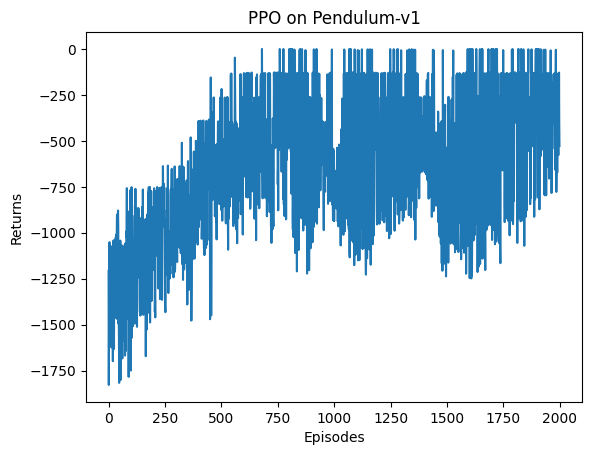

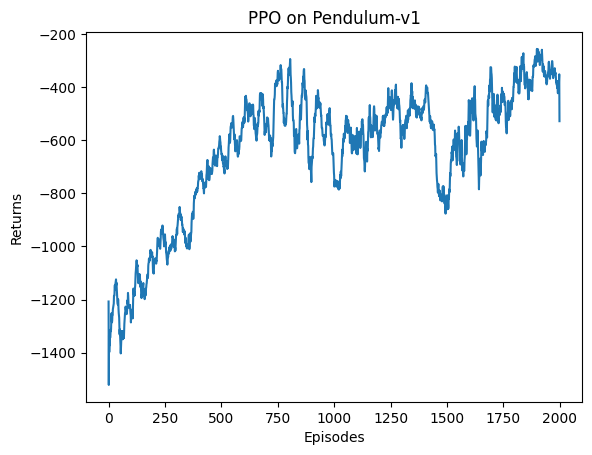

In [19]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('PPO on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 21)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('PPO on {}'.format(env_name))
plt.show()